# Power Consumption Analysis - Tetouan, Morocco

## Data Description

The data signifies power consumption in Tetouan, Morocco, recorded from January 1st, 2017 to December 30th, 2017. This is collected from [Amendis](https://www.amendis.ma/fr), the electricity distributor in that region, and we have obtained this dataset from [Kaggle](https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption/data).

**Feature Variables:**
- Temperature: Measured in Celsius (°C)
- Humidity: Weather humidity
- Wind Speed: Wind speed
- Diffuse Flows: Represents amount of diffused solar radiation

**Response Variables:**
- Zone 1 Power Consumption: Power Consumption in Quads zone (kV)
- Zone 2 Power Consumption: Power Consumption in Smir zone (kV)  
- Zone 3 Power Consumption: Power Consumption in Boussafou zone (kV)

These feature variables were measured in 10-minute intervals throughout the day. We aggregated zones 1, 2, and 3 to analyze the comprehensive power consumption in Tetouan.


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Configure matplotlib for better plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


In [4]:
# Load and preprocess the data
powerconsumption = pd.read_csv('data/powerconsumption.csv')

# Parse datetime column
powerconsumption['Datetime'] = pd.to_datetime(powerconsumption['Datetime'], format='%m/%d/%Y %H:%M')



# Create total consumption by summing all three zones
powerconsumption['total_consumption'] = (powerconsumption['PowerConsumption_Zone1'] + 
                                        powerconsumption['PowerConsumption_Zone2'] + 
                                        powerconsumption['PowerConsumption_Zone3'])
powerconsumption = powerconsumption.drop(columns=['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3'])
powerconsumption = powerconsumption.set_index("Datetime")
powerconsumption


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,total_consumption
Datetime,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,70425.53544
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,69320.84387
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,67803.22193
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,65489.23209
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,63650.44627
...,...,...,...,...,...,...
2017-12-30 23:10:00,7.010,72.4,0.080,0.040,0.096,72798.08659
2017-12-30 23:20:00,6.947,72.6,0.082,0.051,0.093,70983.80786
2017-12-30 23:30:00,6.900,72.8,0.086,0.084,0.074,68675.04965


Daily average consumption data:
         date  avg_daily_consumption
0  2017-01-01           64071.818534
1  2017-01-02           66247.982154
2  2017-01-03           68240.519974
3  2017-01-04           68465.603003
4  2017-01-05           68501.029337


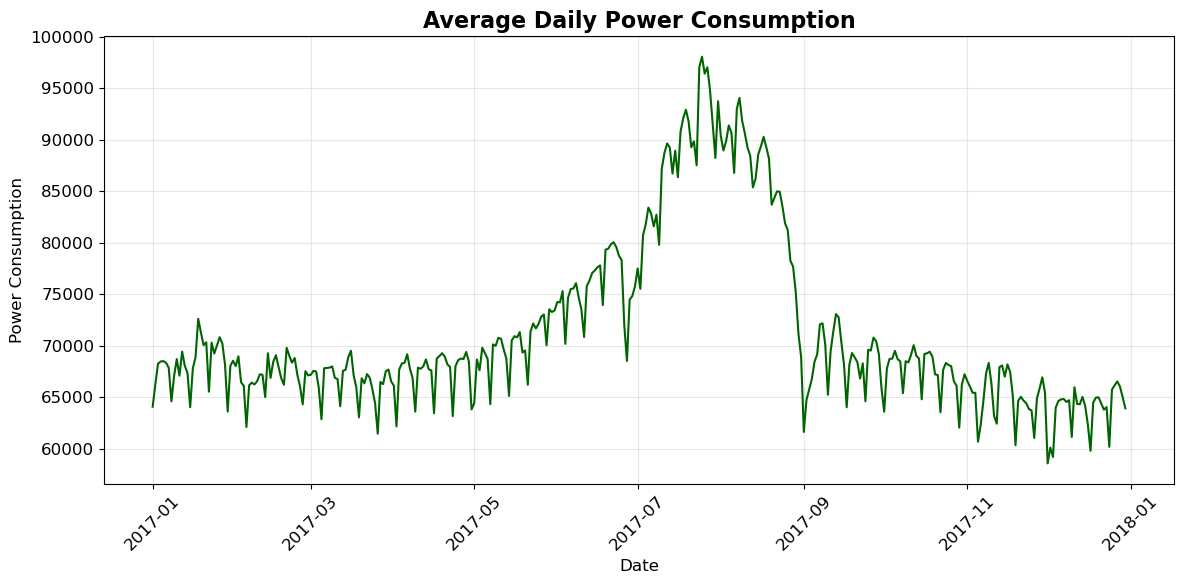


Observation: The average daily power consumption shows an overall trend that peaks in the summer months
and potentially a weekly seasonal trend. The data is not stationary and the variance seems to be constant
disregarding the overall trend.


In [4]:
# Create daily average consumption data
powerconsumption['date'] = powerconsumption['Datetime'].dt.date
avg_daily = powerconsumption.groupby('date')['total_consumption'].mean().reset_index()
avg_daily.columns = ['date', 'avg_daily_consumption']

print("Daily average consumption data:")
print(avg_daily.head())

# Convert date back to datetime for plotting
avg_daily['date'] = pd.to_datetime(avg_daily['date'])

# Plot average daily power consumption
plt.figure(figsize=(12, 6))
plt.plot(avg_daily['date'], avg_daily['avg_daily_consumption'], color='darkgreen', linewidth=1.5)
plt.title('Average Daily Power Consumption', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Power Consumption', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservation: The average daily power consumption shows an overall trend that peaks in the summer months")
print("and potentially a weekly seasonal trend. The data is not stationary and the variance seems to be constant")
print("disregarding the overall trend.")


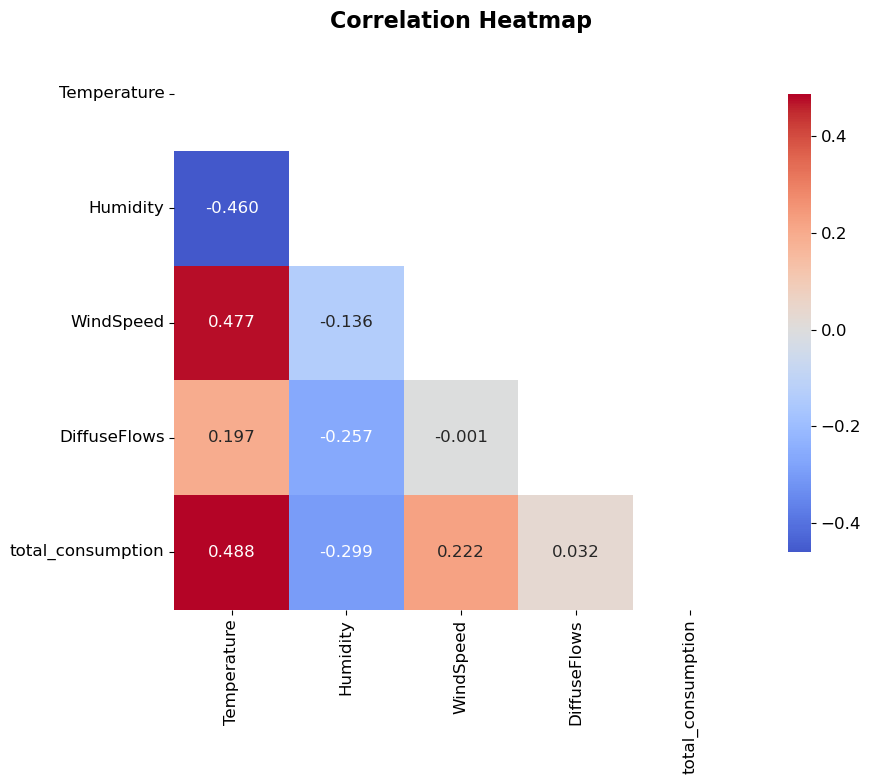

Correlation Matrix:
                   Temperature  Humidity  WindSpeed  DiffuseFlows  \
Temperature              1.000    -0.460      0.477         0.197   
Humidity                -0.460     1.000     -0.136        -0.257   
WindSpeed                0.477    -0.136      1.000        -0.001   
DiffuseFlows             0.197    -0.257     -0.001         1.000   
total_consumption        0.488    -0.299      0.222         0.032   

                   total_consumption  
Temperature                    0.488  
Humidity                      -0.299  
WindSpeed                      0.222  
DiffuseFlows                   0.032  
total_consumption              1.000  

Observation: The Temperature variable seems to be moderately correlated to Humidity,
WindSpeed, and total_consumption.


In [5]:
# Create correlation matrix for relevant variables
corr_variables = ['Temperature', 'Humidity', 'WindSpeed', 'DiffuseFlows', 'total_consumption']
corr_matrix = powerconsumption[corr_variables].corr()

# Create correlation heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Create mask for upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(corr_matrix.round(3))
print("\nObservation: The Temperature variable seems to be moderately correlated to Humidity,")
print("WindSpeed, and total_consumption.")


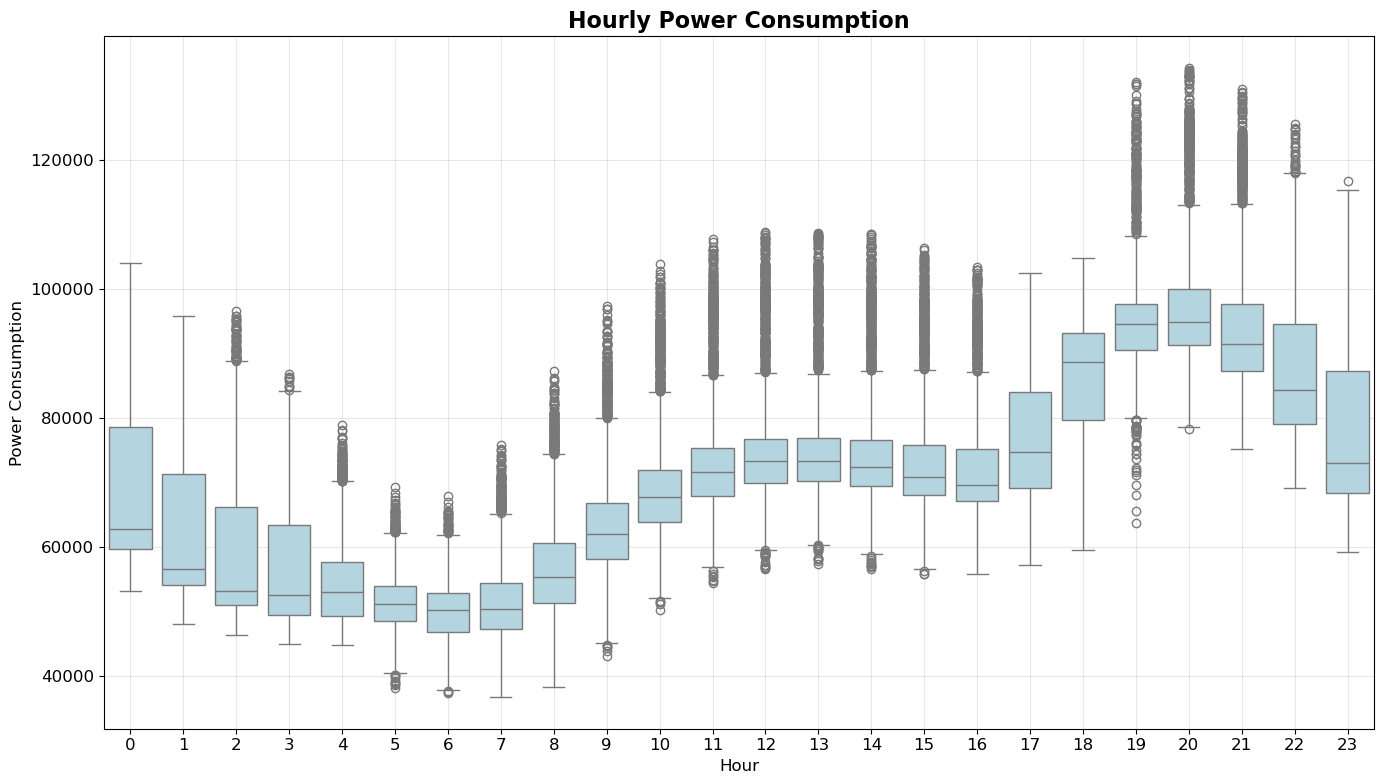

Observation: There is potentially a seasonal trend across the hours of the day.
Lowest consumption is around 6am and increases until about 8pm where it begins to decrease again.


In [6]:
# Extract hour from datetime for hourly analysis
powerconsumption['hour'] = powerconsumption['Datetime'].dt.hour

# Create hourly power consumption boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=powerconsumption, x='hour', y='total_consumption', color='lightblue')
plt.title('Hourly Power Consumption', fontsize=16, fontweight='bold')
plt.xlabel('Hour', fontsize=12)
plt.ylabel('Power Consumption', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation: There is potentially a seasonal trend across the hours of the day.")
print("Lowest consumption is around 6am and increases until about 8pm where it begins to decrease again.")


In [7]:
# Summary statistics
print("=== SUMMARY STATISTICS ===")
print("\nDataset Information:")
print(f"Time period: {powerconsumption['Datetime'].min()} to {powerconsumption['Datetime'].max()}")
print(f"Total number of observations: {len(powerconsumption)}")
print(f"Measurement frequency: Every 10 minutes")

print(f"\nDescriptive Statistics for Key Variables:")
summary_stats = powerconsumption[['Temperature', 'Humidity', 'WindSpeed', 'DiffuseFlows', 'total_consumption']].describe()
print(summary_stats.round(2))

# Check for missing values
print(f"\nMissing Values:")
missing_values = powerconsumption.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found")


=== SUMMARY STATISTICS ===

Dataset Information:
Time period: 2017-01-01 00:00:00 to 2017-12-30 23:50:00
Total number of observations: 52416
Measurement frequency: Every 10 minutes

Descriptive Statistics for Key Variables:
       Temperature  Humidity  WindSpeed  DiffuseFlows  total_consumption
count     52416.00  52416.00   52416.00      52416.00           52416.00
mean         18.81     68.26       1.96         75.03           71222.89
std           5.82     15.55       2.35        124.21           17143.14
min           3.25     11.34       0.05          0.01           36785.04
25%          14.41     58.31       0.08          0.12           56499.07
50%          18.78     69.86       0.09          4.46           69788.79
75%          22.89     81.40       4.92        101.00           83749.17
max          40.01     94.80       6.48        936.00          134208.15

Missing Values:
No missing values found


In [ ]:
def engineer_features(df, target_col):
    """
    Create comprehensive time-series features
    
    Args:
        df: DataFrame with time series data
        target_col: Target column to engineer features for
        
    Returns:
        DataFrame with engineered features
    """
    # Create a copy to avoid modifying original data
    df_features = df.copy()

    # 1. LAG FEATURES
    # These capture autocorrelation - how past values predict future values

    lags = [144]  
    for lag in lags:
        # Target variable lags
        df_features[f'{target_col}_lag_{lag}'] = df_features[target_col].shift(lag)
        
    
    # 2. ROLLING STATISTICS
    # These capture trends and smoothed patterns

    windows = [144,288]
    
    for window in windows:
        # Rolling mean (trend)
        df_features[f'{target_col}_rolling_mean_{window}'] = df_features[target_col].rolling(window=window).mean()
        
        # Rolling std (volatility)
        df_features[f'{target_col}_rolling_std_{window}'] = df_features[target_col].rolling(window=window).std()
        
        # Rolling min/max (range)
        df_features[f'{target_col}_rolling_min_{window}'] = df_features[target_col].rolling(window=window).min()
        df_features[f'{target_col}_rolling_max_{window}'] = df_features[target_col].rolling(window=window).max()
    
    # 3. TEMPORAL FEATURES
    # These capture seasonality and calendar effects

    # Extract basic temporal components
    df_features['hour'] = df_features.index.hour
    #df_features['month'] = df_features.index.month
    #df_features['quarter'] = df_features.index.quarter
    #df_features['year'] = df_features.index.year

    # Cyclical encoding for seasonal patterns
    df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)

    # Drop low importance features
    df_features = df_features.drop(columns=['hour'])

    
    
    df_features = df_features.dropna()
    
    return df_features